In [1]:
import numpy as np
import matplotlib.pyplot as plt
# %matplotlib Tk

# Triads

## Code

In [4]:
kmax=30;kmin=6
n=int(kmax)*2+1
idk=(np.array(np.where(np.zeros([n]*2)==0))-kmax).astype(int)
order=lambda x: ((x[0]+kmax)*n+(x[1]+kmax)).astype(int)

In [5]:
%%time

k=[];p=[];q=[]

for i in range(len(idk.T)):
    tmp1=(np.linalg.norm(idk.T[i].reshape(2,1),axis=0)<=kmax) & (np.linalg.norm(idk,axis=0)<=kmax) & (np.linalg.norm(-idk-idk.T[i].reshape(2,1),axis=0)<=kmax)
    tmp2=(np.linalg.norm(idk.T[i].reshape(2,1),axis=0)>=kmin) & (np.linalg.norm(idk,axis=0)>=kmin) & (np.linalg.norm(-idk-idk.T[i].reshape(2,1),axis=0)>=kmin)
    tmp3=(order(idk.T[i])<order(idk)) & (order(idk)<order(-idk-idk.T[i].reshape(2,1)))
    if (tmp1&tmp2&tmp3).sum()!=0:
        k.append(np.array([idk.T[i]]*(tmp1&tmp2&tmp3).sum()))
        tmp=idk.T[tmp1&tmp2&tmp3]
        p.append(tmp)
        q.append(-tmp-idk.T[i])

k=np.row_stack(k).T;p=np.row_stack(p).T;q=np.row_stack(q).T
kmag=np.linalg.norm(k,axis=0)
pmag=np.linalg.norm(p,axis=0)
qmag=np.linalg.norm(q,axis=0)

CPU times: user 485 ms, sys: 21.3 ms, total: 506 ms
Wall time: 506 ms


In [6]:
A=np.zeros([len(idk.T)]*2);G=np.zeros([len(idk.T)]*2)
A[order(k),order(p)]=1
A[order(k),order(q)]=1
A[order(p),order(q)]=1
A=A+A.T

G[order(k),order(p)]=(kmag**2)*np.cross(q,p,axis=0)
G[order(k),order(q)]=(kmag**2)*np.cross(p,q,axis=0)
G[order(p),order(k)]=(pmag**2)*np.cross(q,k,axis=0)
G[order(p),order(q)]=(pmag**2)*np.cross(k,q,axis=0)
G[order(q),order(k)]=(qmag**2)*np.cross(p,k,axis=0)
G[order(q),order(p)]=(qmag**2)*np.cross(k,p,axis=0)

## Plots (Basic $A$ and $G$)

In [8]:
counts=np.unique(np.column_stack((k,p,q)),axis=1,return_counts=True)

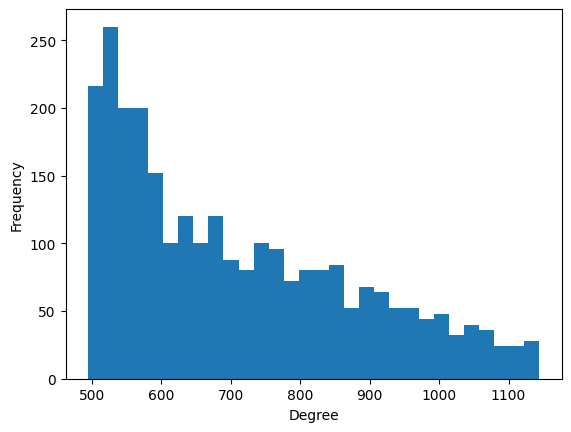

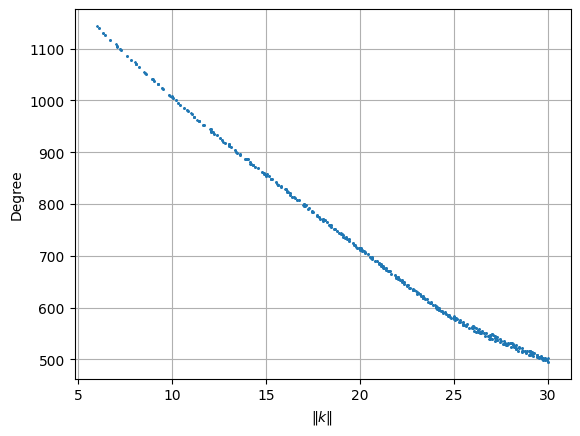

In [9]:
# plt.hist(counts[1],bins=100)
# plt.show()
plt.hist(A[order(counts[0]).astype(int)].sum(axis=1)/2,bins=30)
plt.xlabel('Degree');plt.ylabel('Frequency')
plt.show()

plt.plot(np.linalg.norm(counts[0],axis=0),A[order(counts[0]).astype(int)].sum(axis=1)/2,'.',ms=1)
plt.grid()
plt.xlabel(r'$\|k\|$');plt.ylabel('Degree')
plt.show()

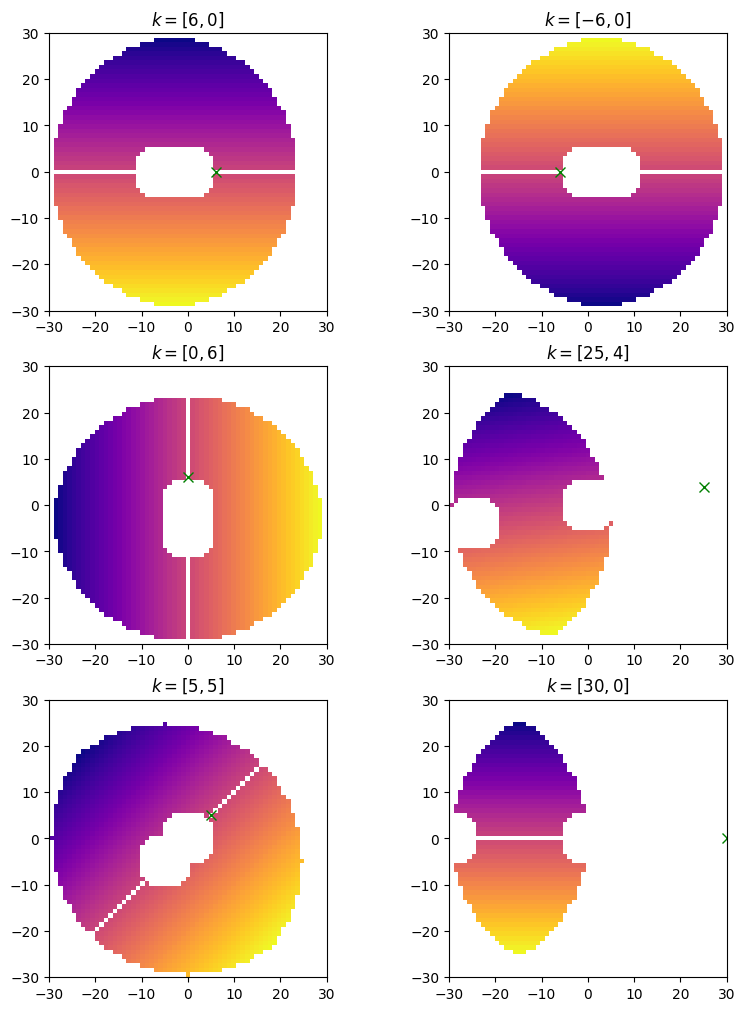

In [10]:
fig,ax=plt.subplots(3,2,layout='constrained',figsize=(8,10))

points=[np.array([6,0]),np.array([-6,0]),np.array([0,6]),np.array([25,4]),np.array([5,5]),np.array([30,0])]
coords=(idk+kmax).astype(int)

for i in range(len(points)):
    grid=np.zeros([n]*2)
    grid[coords[1],coords[0]]=G[order(points[i])]
    grid[grid==0]=None
    ax.flat[i].set_title(rf'$k=[{points[i][0]}, {points[i][1]}]$')
    im=ax.flat[i].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='plasma')
    ax.flat[i].plot(points[i][0],points[i][1],'gx',ms=7)
    # plt.colorbar(im)    
plt.show()

# Analytical $\rho(\vec k)$

$E(\vec k)=\frac12 k^2\rho(\vec k)^2$ and $E(\vec k)\propto k^{-\frac53}$

$\implies\rho(\vec k)^2\propto k^{-\frac{11}3}$

$\implies\rho(\vec k)\propto k^{-\frac{11}6}$

Then,

## Code

In [14]:
def rho(mag):
    return mag**(-11/6)

In [15]:
Grho=np.zeros([len(idk.T)]*2)
Grho[order(k),order(p)]=(kmag**2)*np.cross(q,p,axis=0) * rho(kmag)*rho(pmag)*rho(qmag)
Grho[order(k),order(q)]=(kmag**2)*np.cross(p,q,axis=0) * rho(kmag)*rho(pmag)*rho(qmag)
Grho[order(p),order(k)]=(pmag**2)*np.cross(q,k,axis=0) * rho(kmag)*rho(pmag)*rho(qmag)
Grho[order(p),order(q)]=(pmag**2)*np.cross(k,q,axis=0) * rho(kmag)*rho(pmag)*rho(qmag)
Grho[order(q),order(k)]=(qmag**2)*np.cross(p,k,axis=0) * rho(kmag)*rho(pmag)*rho(qmag)
Grho[order(q),order(p)]=(qmag**2)*np.cross(k,p,axis=0) * rho(kmag)*rho(pmag)*rho(qmag)

## Plots

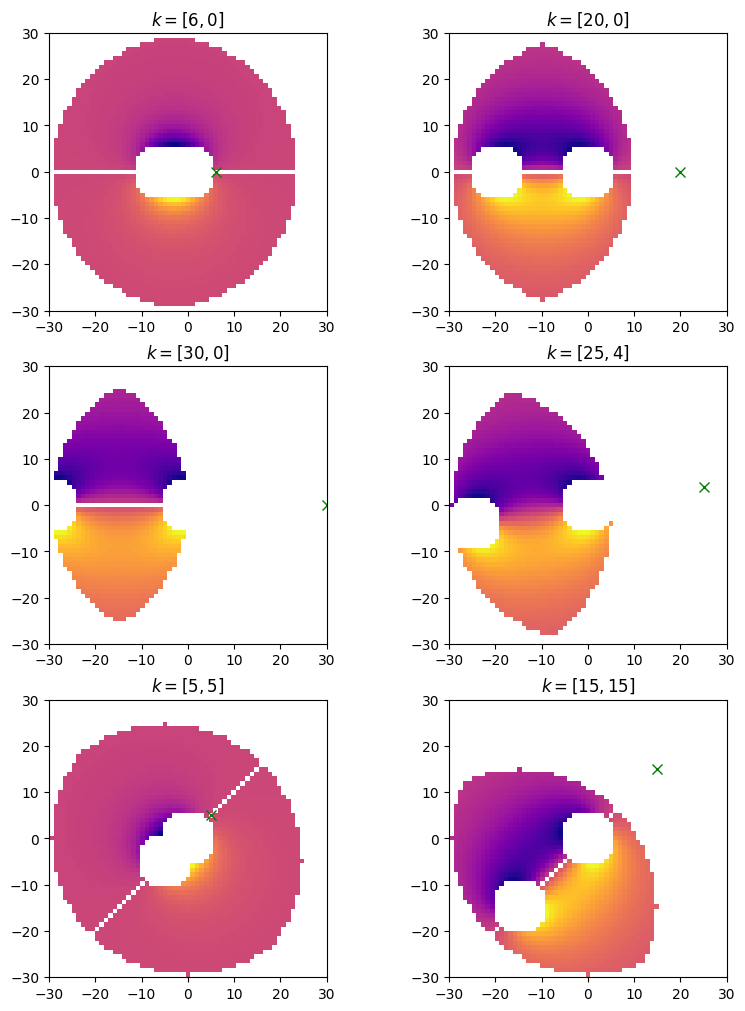

In [17]:
fig,ax=plt.subplots(3,2,layout='constrained',figsize=(8,10))

points=[np.array([6,0]),np.array([20,0]),np.array([30,0]),np.array([25,4]),np.array([5,5]),np.array([15,15])]
coords=(idk+kmax).astype(int)

for i in range(len(points)):
    grid=np.zeros([n]*2)
    grid[coords[1],coords[0]]=Grho[order(points[i])]
    grid[grid==0]=None
    ax.flat[i].set_title(rf'$k=[{points[i][0]}, {points[i][1]}]$')
    im=ax.flat[i].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='plasma')
    ax.flat[i].plot(points[i][0],points[i][1],'gx',ms=7)
    # plt.colorbar(im)    
plt.show()

# Data $\rho(\vec k)$

## Code

In [21]:
from scipy.optimize import curve_fit

In [22]:
path='./data/'
triads=np.loadtxt(path+'triads.txt')
k_data=triads[:,[0,1]].T
p_data=triads[:,[2,3]].T
q_data=-k_data-p_data

k_order=order(k_data).argsort()
p_order=order(p_data).argsort()
q_order=order(q_data).argsort()

k_data=k_data[:,k_order]
p_data=p_data[:,p_order]
q_data=q_data[:,q_order]

kmag_data=np.linalg.norm(k_data,axis=0)
pmag_data=np.linalg.norm(p_data,axis=0)
qmag_data=np.linalg.norm(q_data,axis=0)

rhok=np.load(path+'rhok.npy').astype(np.float64)[0,k_order]
rhop=np.load(path+'rhop.npy').astype(np.float64)[0,p_order]
rhoq=np.load(path+'rhoq.npy').astype(np.float64)[0,q_order]

# plt.plot(kmag_data,rhok,'.',ms=1)
# plt.plot(pmag_data,rhop,'.',ms=1)
# plt.plot(qmag_data,rhoq,'.',ms=1)
# plt.show()

all_mag=np.array([kmag_data,pmag_data,qmag_data]).flatten()
all_rho=np.array([rhok,rhop,rhoq]).flatten()

### Fitting $ak^{-\frac{11}6}$

a = [0.5448111]


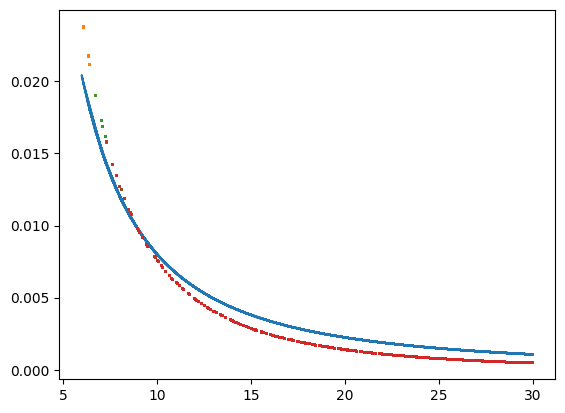

In [24]:
def f(x,a):
    return a*(x**(-11/6))

a=curve_fit(f,all_mag,all_rho)[0]
print(f'a = {a}')

plt.plot(kmag,f(kmag,a))
plt.plot(kmag_data,rhok,'.',ms=1)
plt.plot(pmag_data,rhop,'.',ms=1)
plt.plot(qmag_data,rhoq,'.',ms=1)
plt.show()

### Fitting $ak^{b}$

a = 1.657861386762042, b = -2.3439511091862633


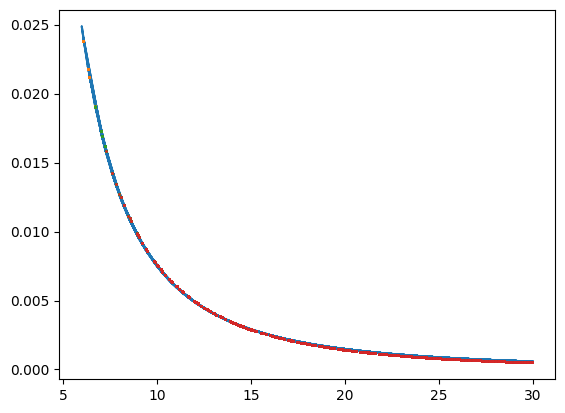

In [26]:
def f(x,a,b):
    return a*(x**b)

a,b=curve_fit(f,all_mag,all_rho)[0]
print(f'a = {a}, b = {b}')

plt.plot(kmag,f(kmag,a,b))
plt.plot(kmag_data,rhok,'.',ms=1)
plt.plot(pmag_data,rhop,'.',ms=1)
plt.plot(qmag_data,rhoq,'.',ms=1)
plt.show()

In [27]:
-2.3439511091862633*3

-7.03185332755879

In [28]:
Grho=np.zeros([len(idk.T)]*2)
Grho[order(k),order(p)]=(kmag**2)*np.cross(q,p,axis=0) * f(kmag,a,b)*f(pmag,a,b)*f(qmag,a,b)
Grho[order(k),order(q)]=(kmag**2)*np.cross(p,q,axis=0) * f(kmag,a,b)*f(pmag,a,b)*f(qmag,a,b)
Grho[order(p),order(k)]=(pmag**2)*np.cross(q,k,axis=0) * f(kmag,a,b)*f(pmag,a,b)*f(qmag,a,b)
Grho[order(p),order(q)]=(pmag**2)*np.cross(k,q,axis=0) * f(kmag,a,b)*f(pmag,a,b)*f(qmag,a,b)
Grho[order(q),order(k)]=(qmag**2)*np.cross(p,k,axis=0) * f(kmag,a,b)*f(pmag,a,b)*f(qmag,a,b)
Grho[order(q),order(p)]=(qmag**2)*np.cross(k,p,axis=0) * f(kmag,a,b)*f(pmag,a,b)*f(qmag,a,b)

## Plots

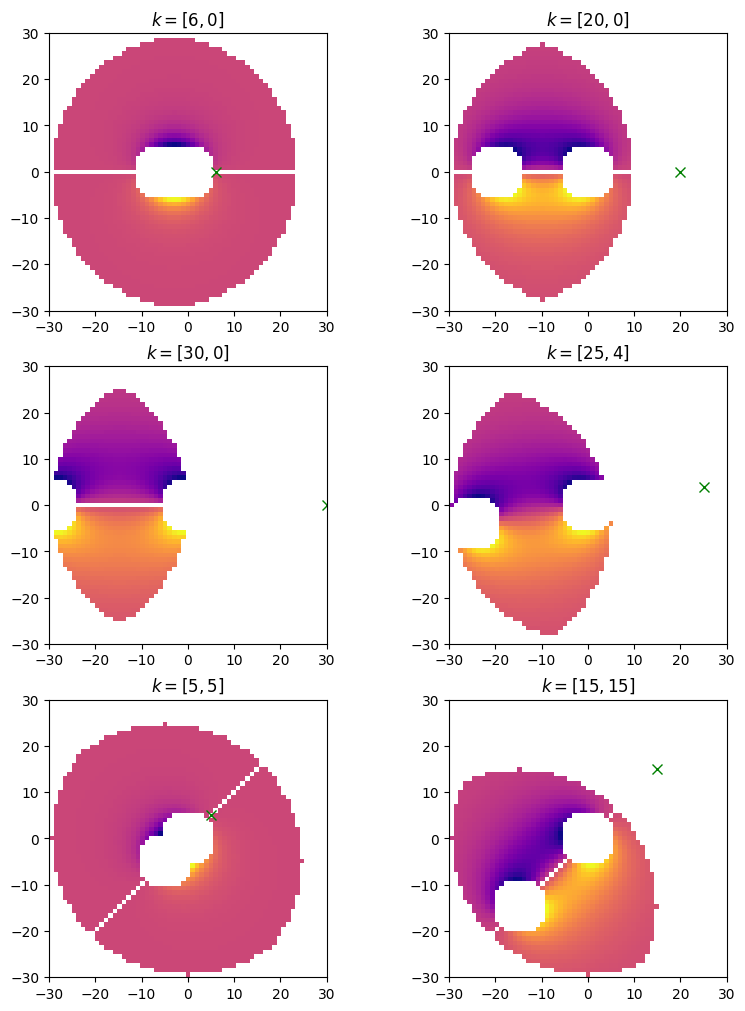

In [30]:
fig,ax=plt.subplots(3,2,layout='constrained',figsize=(8,10))

points=[np.array([6,0]),np.array([20,0]),np.array([30,0]),np.array([25,4]),np.array([5,5]),np.array([15,15])]
coords=(idk+kmax).astype(int)

for i in range(len(points)):
    grid=np.zeros([n]*2)
    grid[coords[1],coords[0]]=Grho[order(points[i])]
    grid[grid==0]=None
    ax.flat[i].set_title(rf'$k=[{points[i][0]}, {points[i][1]}]$')
    im=ax.flat[i].imshow(grid,extent=[-kmax,kmax,-kmax,kmax],origin='lower',cmap='plasma')
    ax.flat[i].plot(points[i][0],points[i][1],'gx',ms=7)
    # plt.colorbar(im)    
plt.show()